In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_score, recall_score
)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

## Data Loading

Loading all 8 days of CICIDS2017 CSVs and concatenating them into one dataframe.
Any flow that isn't labelled `BENIGN` gets `is_attack = 1`.

In [2]:
all_files = [
    'data/Monday-WorkingHours.pcap_ISCX.csv',
    'data/Tuesday-WorkingHours.pcap_ISCX.csv',
    'data/Wednesday-workingHours.pcap_ISCX.csv',
    'data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'data/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
]

dfs = []
for path in all_files:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all['is_attack'] = (df_all['Label'] != 'BENIGN').astype(int)

print(f"Total samples : {len(df_all):,}  |  Attack rate: {df_all['is_attack'].mean():.2%}")
print(f"\nLabel distribution:\n{df_all['Label'].value_counts()}")

Total samples : 2,830,743  |  Attack rate: 19.70%

Label distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


## Feature Engineering & Preprocessing

Picking the 21 features: packet rates, byte counts, inter-arrival times, TCP flags, etc.

3-way stratified split: 72% train / 8% val / 20% test. `StandardScaler` is fit on training data only. Val set is used exclusively for threshold tuning, test set is held out until final evaluation.

### Feature Set

| Group | Features | Why it matters |
|---|---|---|
| Flow | Duration, Fwd/Bwd packet counts, Total Bwd bytes | Basic shape of a flow |
| Port | Destination Port | FTP (21) / SSH (22) are common brute-force targets |
| Packet size | Fwd/Bwd/overall mean & std | Attack traffic tends to use uniformly small packets |
| Timing | Flow IAT mean & std | Scripted attacks are way more regular than human traffic |
| Rates | Flow/Fwd/Bwd packets/s | Volumetric attacks stand out immediately |
| Flags | SYN, ACK, RST counts | TCP handshake patterns look different under attack |
| Ratio | Average packet size, Down/Up ratio | Asymmetric traffic is a useful signal |

In [3]:
features_v2 = [
    # flow
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Bwd Packets',
    'Flow Packets/s',
    # tcp flags
    'SYN Flag Count',
    'ACK Flag Count',
    'RST Flag Count',
    # dest port
    'Destination Port',
    # packet length stats
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Packet Length Mean',
    'Packet Length Std',
    # inter arrival time
    'Flow IAT Mean',
    'Flow IAT Std',
    # packet rates
    'Fwd Packets/s',
    'Bwd Packets/s',
    # size/ratio
    'Average Packet Size',
    'Down/Up Ratio',
]

print(f"Feature count: {len(features_v2)}")

Feature count: 21


In [ ]:
X_all = (df_all[features_v2]
         .replace([np.inf, -np.inf], np.nan)
         .dropna())
y_all      = df_all.loc[X_all.index, 'is_attack']
labels_all = df_all.loc[X_all.index, 'Label']

# 80/20 trainval/test, then 90/10 train/val from trainval
# 72% train, 8% val, 20% test
X_trainval_raw, X_test_raw, y_trainval, y_test, labels_trainval, labels_test = train_test_split(
    X_all, y_all, labels_all, test_size=0.2, random_state=42, stratify=y_all
)
X_train_raw, X_val_raw, y_train, y_val, labels_train, labels_val = train_test_split(
    X_trainval_raw, y_trainval, labels_trainval, test_size=0.1, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f"Training samples : {len(X_train_raw):,}  |  Attack rate: {y_train.mean():.2%}")
print(f"Val samples      : {len(X_val_raw):,}  |  Attack rate: {y_val.mean():.2%}")
print(f"Test samples     : {len(X_test_raw):,}  |  Attack rate: {y_test.mean():.2%}")

Training samples : 2,036,070  |  Attack rate: 19.68%
Val samples      : 226,230  |  Attack rate: 19.68%
Test samples     : 565,576  |  Attack rate: 19.68%


## PCA Dimensionality Reduction

Running PCA on the 21 scaled features to reduce noise and deal with collinearity before handing off to logistic regression.

Fit on training data only using same transform applied to the test split.

In [5]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Components retained (95% variance): {pca.n_components_} of {X_train_scaled.shape[1]}")
print(f"Total explained variance:           {pca.explained_variance_ratio_.sum():.4f}")
print(f"Training shape after PCA:           {X_train_pca.shape}")

Components retained (95% variance): 11 of 21
Total explained variance:           0.9597
Training shape after PCA:           (2036070, 11)


## Logistic Regression

Training LR on the PCA-reduced features. Using `class_weight='balanced'` because the dataset is heavily skewed toward benign traffic.

The main reason LR was chosen as node1's model is that it's more easily exportable to JSON and can be inferred in Go with no Python at runtime 

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_pca, y_train)

y_pred = lr.predict(X_test_pca)
y_prob = lr.predict_proba(X_test_pca)[:, 1]

print("Logistic Regression - Test Performance (Friday)")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

Logistic Regression - Test Performance (Friday)
              precision    recall  f1-score   support

      Benign       0.95      0.85      0.89    454265
      Attack       0.56      0.80      0.66    111311

    accuracy                           0.84    565576
   macro avg       0.75      0.82      0.78    565576
weighted avg       0.87      0.84      0.85    565576



In [7]:
attack_types = sorted(t for t in labels_test.unique() if t != 'BENIGN')
rows = []
for attack in attack_types:
    mask = (labels_test == attack).values
    if mask.sum() == 0:
        continue
    rows.append({
        'Attack'  : attack,
        'Samples' : int(mask.sum()),
        'Recall'  : y_pred[mask].mean(),
    })

fpr_val = y_pred[(y_test == 0).values].mean()
df_breakdown = pd.DataFrame(rows).sort_values('Samples', ascending=False)
df_breakdown['Recall'] = df_breakdown['Recall'].map(lambda x: f'{x:.2%}')

print(f"False Positive Rate on benign traffic: {fpr_val:.2%}\n")
print("Per-attack-type detection recall:")
print(df_breakdown.to_string(index=False))

False Positive Rate on benign traffic: 15.46%

Per-attack-type detection recall:
                    Attack  Samples Recall
                  DoS Hulk    46258 94.85%
                  PortScan    31835 51.64%
                      DDoS    25301 99.98%
             DoS GoldenEye     2098 73.59%
               FTP-Patator     1595  1.57%
               SSH-Patator     1211 47.65%
             DoS slowloris     1128 48.58%
          DoS Slowhttptest     1083 56.51%
                       Bot      376 15.43%
  Web Attack � Brute Force      290 88.97%
          Web Attack � XSS      126 96.03%
              Infiltration        5 20.00%
Web Attack � Sql Injection        3 33.33%
                Heartbleed        2  0.00%


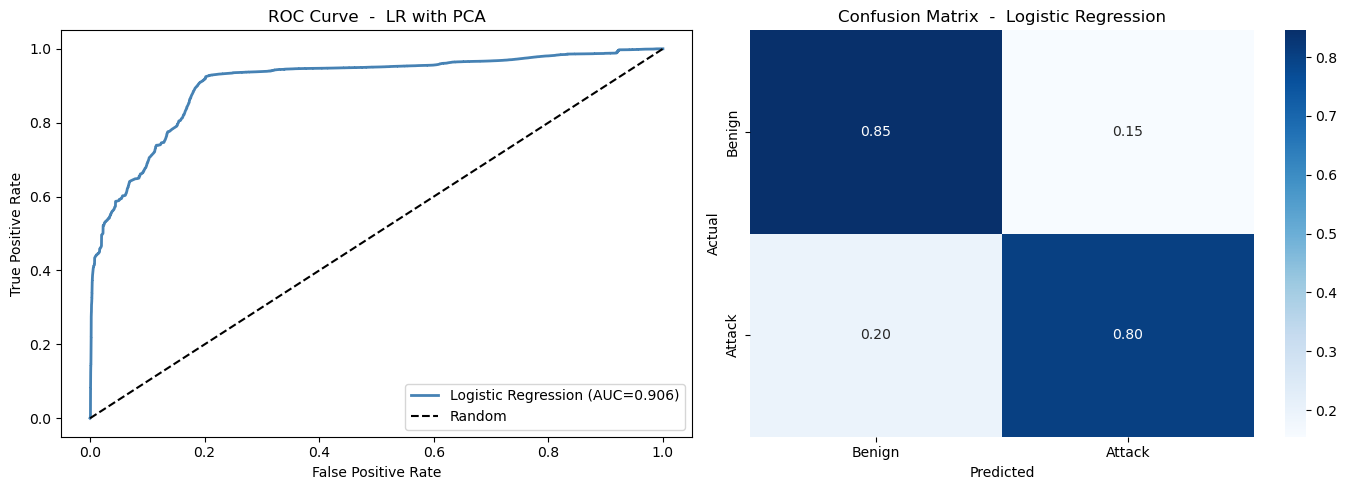

In [8]:
fpr_roc, tpr_roc, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr_roc, tpr_roc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_roc, tpr_roc, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC={roc_auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve  -  LR with PCA')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix  -  Logistic Regression')

plt.tight_layout()
plt.show()

## Model Comparison

Training four models on the same 21 scaled features to see where LR sits relative to stronger alternatives:

| Model | Features | Notes |
|---|---|---|
| Logistic Regression (PCA) | 21 -> PCA | What node1 actually uses |
| Decision Tree | 21 scaled | node2's model  -  easy to export to JSON |
| Random Forest | 21 scaled | Ensemble baseline |
| XGBoost | 21 scaled | Gradient boosted trees |
| MLP | 21 scaled | node3's model  -  shallow neural net |

LR ends up weaker than the others in raw F1. node1's linear boundary means it disagrees with nodes 2 and 3 on borderline flows, which is what makes the consensus vote meaningful.

> Random Forest and XGBoost take a few minutes on 2.2M training samples. (Apple M2)

In [9]:
# Collect comparison results  -  populated by each model cell below
comparison_results = {}

comparison_results['LR + PCA'] = {
    'y_pred': y_pred,
    'y_prob': y_prob,
    'train_time': None,
}

### Decision Tree

In [10]:
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train)
dt_train_time = time.time() - t0

dt_pred = dt.predict(X_test_scaled)
dt_prob = dt.predict_proba(X_test_scaled)[:, 1]

print(f"Decision Tree  -  train time: {dt_train_time:.1f}s")
print(classification_report(y_test, dt_pred, target_names=['Benign', 'Attack']))

comparison_results['Decision Tree'] = {
    'y_pred': dt_pred,
    'y_prob': dt_prob,
    'train_time': dt_train_time,
}

Decision Tree  -  train time: 27.7s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    454265
      Attack       0.99      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      1.00      0.99    565576
weighted avg       1.00      1.00      1.00    565576



### Random Forest

In [11]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train_scaled, y_train)
rf_train_time = time.time() - t0

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Random Forest  -  train time: {rf_train_time:.1f}s")
print(classification_report(y_test, rf_pred, target_names=['Benign', 'Attack']))

comparison_results['Random Forest'] = {
    'y_pred': rf_pred,
    'y_prob': rf_prob,
    'train_time': rf_train_time,
}

Random Forest  -  train time: 72.0s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    454265
      Attack       0.98      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      1.00      0.99    565576
weighted avg       1.00      1.00      1.00    565576



### XGBoost

In [12]:
if HAS_XGB:
    # scale_pos_weight balances the class imbalance (benign:attack ~ 4:1)
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    t0 = time.time()
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
    )
    xgb_model.fit(X_train_scaled, y_train)
    xgb_train_time = time.time() - t0

    xgb_pred = xgb_model.predict(X_test_scaled)
    xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

    print(f"XGBoost  -  train time: {xgb_train_time:.1f}s")
    print(classification_report(y_test, xgb_pred, target_names=['Benign', 'Attack']))

    comparison_results['XGBoost'] = {
        'y_pred': xgb_pred,
        'y_prob': xgb_prob,
        'train_time': xgb_train_time,
    }
else:
    print("XGBoost not available")

XGBoost  -  train time: 7.7s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    454265
      Attack       0.99      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      1.00      0.99    565576
weighted avg       1.00      1.00      1.00    565576



### MLP (Multilayer Perceptron)

In [13]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False,
)
mlp.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - t0

mlp_pred = mlp.predict(X_test_scaled)
mlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]

print(f"MLP  -  train time: {mlp_train_time:.1f}s  ({mlp.n_iter_} iterations)")
print(classification_report(y_test, mlp_pred, target_names=['Benign', 'Attack']))

comparison_results['MLP'] = {
    'y_pred': mlp_pred,
    'y_prob': mlp_prob,
    'train_time': mlp_train_time,
}

MLP  -  train time: 142.1s  (50 iterations)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    454265
      Attack       0.99      0.99      0.99    111311

    accuracy                           0.99    565576
   macro avg       0.99      0.99      0.99    565576
weighted avg       0.99      0.99      0.99    565576



### Comparison Summary

In [14]:
rows = []
for name, res in comparison_results.items():
    yp = res['y_pred']
    yprob = res['y_prob']
    fpr_r, tpr_r, _ = roc_curve(y_test, yprob)
    roc_auc = auc(fpr_r, tpr_r)
    fpr_val = yp[(y_test == 0).values].mean()
    rows.append({
        'Model'          : name,
        'Precision'      : precision_score(y_test, yp),
        'Recall'         : recall_score(y_test, yp),
        'F1 (attack)'    : f1_score(y_test, yp),
        'AUC'            : roc_auc,
        'FPR'            : fpr_val,
        'Train time (s)' : f"{res['train_time']:.1f}" if res['train_time'] else ' - ',
    })

df_cmp = pd.DataFrame(rows).set_index('Model')
df_cmp[['Precision','Recall','F1 (attack)','AUC','FPR']] = \
    df_cmp[['Precision','Recall','F1 (attack)','AUC','FPR']].applymap(lambda x: f'{x:.3f}')

print("Model Comparison  -  CICIDS2017 test set (20% holdout, stratified)\n")
print(df_cmp.to_string())

Model Comparison  -  CICIDS2017 test set (20% holdout, stratified)

              Precision Recall F1 (attack)    AUC    FPR Train time (s)
Model                                                                  
LR + PCA          0.560  0.803       0.660  0.906  0.155             - 
Decision Tree     0.987  0.994       0.991  0.999  0.003           27.7
Random Forest     0.984  0.994       0.989  1.000  0.004           72.0
XGBoost           0.986  0.995       0.991  1.000  0.003            7.7
MLP               0.987  0.986       0.987  1.000  0.003          142.1


/var/folders/b6/h4f4ql1n7g90f64t30qhp2wc0000gn/T/ipykernel_44788/2750629701.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cmp[['Precision','Recall','F1 (attack)','AUC','FPR']].applymap(lambda x: f'{x:.3f}')


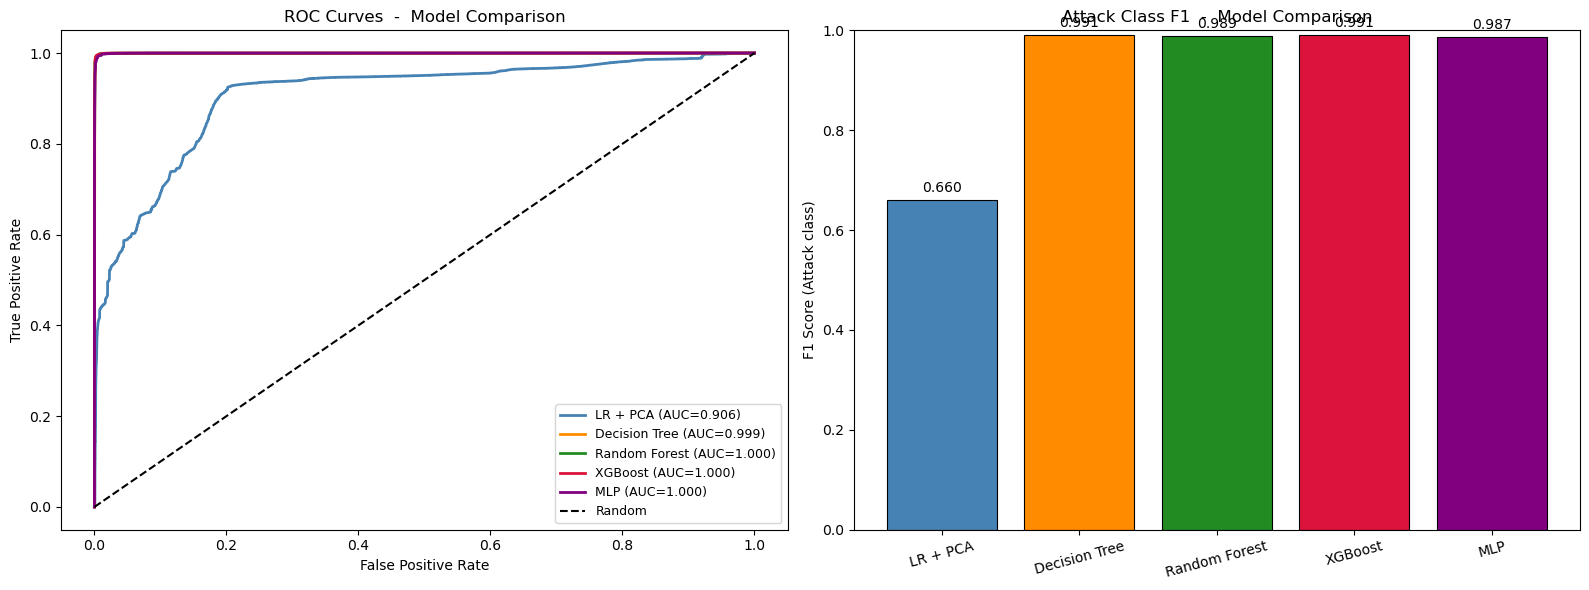

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
for (name, res), color in zip(comparison_results.items(), colors):
    fpr_r, tpr_r, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr_r, tpr_r)
    axes[0].plot(fpr_r, tpr_r, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves  -  Model Comparison')
axes[0].legend(fontsize=9)

# F1 bar chart
model_names = list(comparison_results.keys())
f1_scores = [f1_score(y_test, res['y_pred']) for res in comparison_results.values()]
bar_colors = colors[:len(model_names)]
bars = axes[1].bar(model_names, f1_scores, color=bar_colors, edgecolor='black', linewidth=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('F1 Score (Attack class)')
axes[1].set_title('Attack Class F1  -  Model Comparison')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Export Model Parameters for Go Node

Dumping the scaler, PCA, and LR parameters to JSON so the Go node can do inference without needing Python at runtime.

The Go inference pipeline is just:
1. Scale: `z = (x - scaler_mean) / scaler_scale`
2. Project: `p = pca_components @ (z - pca_mean)`
3. Score: `logit = dot(lr_coef, p) + lr_intercept`
4. Classify: `sigmoid(logit) > lr_threshold`

In [16]:
import json

params = {
    'features'       : features_v2,
    'n_features'     : len(features_v2),
    'n_components'   : int(pca.n_components_),
    'scaler_mean'    : scaler.mean_.tolist(),
    'scaler_scale'   : scaler.scale_.tolist(),
    'pca_mean'       : pca.mean_.tolist(),
    'pca_components' : pca.components_.tolist(),  # [n_components][n_features]
    'lr_coef'        : lr.coef_[0].tolist(),      # [n_components]
    'lr_intercept'   : float(lr.intercept_[0]),
    'lr_threshold'   : 0.5,
}

with open('model_params.json', 'w') as f:
    json.dump(params, f, indent=2)

print("Saved model_params.json")
print(f"  Features    : {len(features_v2)}")
print(f"  PCA comps   : {pca.n_components_} (of {len(features_v2)})")
print(f"  LR coef     : [{len(lr.coef_[0])}] coefficients")
print(f"  LR intercept: {lr.intercept_[0]:.6f}")
print(f"  LR threshold: 0.5")

Saved model_params.json
  Features    : 21
  PCA comps   : 11 (of 21)
  LR coef     : [11] coefficients
  LR intercept: -1.875091
  LR threshold: 0.5


## Per-Node Model Training

Each node gets a different model architecture on purpose  -  the idea is that different model types fail on different flows, so when they disagree it's actually meaningful.

| Node | Model | Why |
|---|---|---|
| node1 | LR + PCA (90% variance, 9 components) | Linear boundary  -  intentionally conservative, creates disagreement |
| node2 | Decision Tree (max_depth=20) | High recall, non-linear, completely different failure modes to LR |
| node3 | MLP (64->32 hidden, ReLU) | Neural net  -  captures patterns neither of the others will |

All three trained on the full 8-day dataset (80% split). Thresholds are tuned per node rather than just using 0.5.

## Per-Node Threshold Tuning

Thresholds are tuned by maximising F1 on the **val set** (not the test set). Final metrics are reported on the held-out test set using that threshold.

In [17]:
from sklearn.metrics import precision_recall_curve
import json

def tune_threshold(y_true, y_prob):
    """Return threshold that maximises F1 on the provided set."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
    best_idx = f1s.argmax()
    return float(thresholds[best_idx]), float(f1s[best_idx])


# node1: Logistic Regression + PCA (90% variance)
print("-- node1: LR + PCA --")
pca1 = PCA(n_components=0.90, random_state=42)
X_tr1  = pca1.fit_transform(X_train_scaled)
X_val1 = pca1.transform(X_val_scaled)
X_te1  = pca1.transform(X_test_scaled)

lr1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr1.fit(X_tr1, y_train)

val_prob1 = lr1.predict_proba(X_val1)[:, 1]
thresh1, f1_val1 = tune_threshold(y_val, val_prob1)   # tune on val
test_prob1 = lr1.predict_proba(X_te1)[:, 1]
pred1 = (test_prob1 >= thresh1).astype(int)
print(f"  PCA components: {pca1.n_components_}  threshold: {thresh1:.4f}  val F1: {f1_val1:.3f}")
print(classification_report(y_test, pred1, target_names=['Benign', 'Attack'], digits=3))

params1 = {
    'model_type'    : 'lr_pca',
    'features'      : features_v2,
    'n_features'    : len(features_v2),
    'n_components'  : int(pca1.n_components_),
    'scaler_mean'   : scaler.mean_.tolist(),
    'scaler_scale'  : scaler.scale_.tolist(),
    'pca_mean'      : pca1.mean_.tolist(),
    'pca_components': pca1.components_.tolist(),
    'lr_coef'       : lr1.coef_[0].tolist(),
    'lr_intercept'  : float(lr1.intercept_[0]),
    'lr_threshold'  : thresh1,
}
with open('model_node1.json', 'w') as f:
    json.dump(params1, f, indent=2)
print("  Saved model_node1.json\n")


# node2: Decision Tree
print("-- node2: Decision Tree --")
dt2 = DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42)
dt2.fit(X_train_scaled, y_train)

val_prob2 = dt2.predict_proba(X_val_scaled)[:, 1]
thresh2, f1_val2 = tune_threshold(y_val, val_prob2)   # tune on val
test_prob2 = dt2.predict_proba(X_test_scaled)[:, 1]
pred2 = (test_prob2 >= thresh2).astype(int)
print(f"  Nodes: {dt2.tree_.node_count}  threshold: {thresh2:.4f}  val F1: {f1_val2:.3f}")
print(classification_report(y_test, pred2, target_names=['Benign', 'Attack'], digits=3))

tree = dt2.tree_
vals = tree.value  # [n_nodes, 1, 2]
attack_prob = []
for i in range(tree.node_count):
    total = vals[i, 0, 0] + vals[i, 0, 1]
    attack_prob.append(float(vals[i, 0, 1] / total) if total > 0 else 0.0)

params2 = {
    'model_type'     : 'decision_tree',
    'features'       : features_v2,
    'n_features'     : len(features_v2),
    'scaler_mean'    : scaler.mean_.tolist(),
    'scaler_scale'   : scaler.scale_.tolist(),
    'lr_threshold'   : thresh2,
    'n_nodes'        : int(tree.node_count),
    'children_left'  : tree.children_left.tolist(),
    'children_right' : tree.children_right.tolist(),
    'feature'        : tree.feature.tolist(),
    'threshold'      : tree.threshold.tolist(),
    'value'          : attack_prob,
}
with open('model_node2.json', 'w') as f:
    json.dump(params2, f, indent=2)
print("  Saved model_node2.json\n")


# node3: MLP (64 -> 32 -> 1, ReLU hidden, sigmoid output)
print("-- node3: MLP --")
mlp3 = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False,
)
mlp3.fit(X_train_scaled, y_train)

val_prob3 = mlp3.predict_proba(X_val_scaled)[:, 1]
thresh3, f1_val3 = tune_threshold(y_val, val_prob3)   # tune on val
test_prob3 = mlp3.predict_proba(X_test_scaled)[:, 1]
pred3 = (test_prob3 >= thresh3).astype(int)
print(f"  Iterations: {mlp3.n_iter_}  threshold: {thresh3:.4f}  val F1: {f1_val3:.3f}")
print(classification_report(y_test, pred3, target_names=['Benign', 'Attack'], digits=3))

weights = [w.T.tolist() for w in mlp3.coefs_]
biases  = [b.tolist()   for b in mlp3.intercepts_]

params3 = {
    'model_type'  : 'mlp',
    'features'    : features_v2,
    'n_features'  : len(features_v2),
    'scaler_mean' : scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'lr_threshold': thresh3,
    'weights'     : weights,
    'biases'      : biases,
}
with open('model_node3.json', 'w') as f:
    json.dump(params3, f, indent=2)
print("  Saved model_node3.json")

-- node1: LR + PCA --
  PCA components: 9  threshold: 0.5980  val F1: 0.669
              precision    recall  f1-score   support

      Benign      0.911     0.939     0.925    454265
      Attack      0.715     0.626     0.667    111311

    accuracy                          0.877    565576
   macro avg      0.813     0.782     0.796    565576
weighted avg      0.872     0.877     0.874    565576

  Saved model_node1.json

-- node2: Decision Tree --
  Nodes: 3161  threshold: 0.8698  val F1: 0.992
              precision    recall  f1-score   support

      Benign      0.998     0.998     0.998    454265
      Attack      0.993     0.991     0.992    111311

    accuracy                          0.997    565576
   macro avg      0.995     0.995     0.995    565576
weighted avg      0.997     0.997     0.997    565576

  Saved model_node2.json

-- node3: MLP --
  Iterations: 50  threshold: 0.4682  val F1: 0.986
              precision    recall  f1-score   support

      Benign      0.